Snow Depth Analysis Notebook
Made by Zane Pederson

In [23]:
from pathlib import Path #to access data by path
import topotoolbox as ttb #to handle data
import matplotlib.pyplot as plt #for plotting
import numpy as np #for handling large amounts of data (arrays not lists)
from datetime import datetime as dt #to process the date of dems
import rioxarray as rxr

Here we create a list of independent variables that we will plot in relation to snow depth. This includes: Burn Severity, Slope, Aspect, and Northness.

In [24]:
bsDem = ttb.read_tif(r"NonDepthData\MTBS_Resampled_1m.tif") #raster containing burn severity data
sfDem = ttb.read_tif(r"NonDepthData\DEM_063025_SnowFree.tif") #raster of snow free slope (used for slope, aspect, & northness)

#remove 10 edge pixels on independent dems
sfDem = sfDem.crop(10, sfDem.columns - 10, sfDem.rows - 10, 10, 'pixel')
bsDem = bsDem.crop(10, bsDem.columns - 10, bsDem.rows - 10, 10, 'pixel')

#get slope dem
slopeData = sfDem.gradient8(unit='degree').z #create a matrix
slopeData[slopeData > 80] = np.nan #filter out angles over 80 degrees
slopeData[slopeData < 0] = np.nan #filter out angles less than 0 degrees
slopeDem = sfDem.duplicate_with_new_data(slopeData) #create a new dem containing slope as z

#get aspect dem
aspectData = sfDem.aspect().z
aspectData[aspectData > 360] = np.nan #filter out angles over 360 degrees
aspectData[aspectData < 0] = np.nan #filter out angles less than 0 degrees
aspectDem = sfDem.duplicate_with_new_data(aspectData) 

#get northness dem
northnessData = np.cos(np.radians(aspectData))
northnessDem = sfDem.duplicate_with_new_data(northnessData)

#set names
bsDem.name = "Burn Severity"
sfDem.name = "Snow Free Slope"
slopeDem.name = "Slope"
aspectDem.name = "Aspect"
northnessDem.name = "Northness"

Functions that filter and resample data (resample call filterLidarDepth) to ensure accuracy. Resample also clips 10 pixels from the borders of each raster.

In [25]:
#filter out any points less than -0.1 or greater than 5, if a remaining value is less than 0 it will be set to zero
def filterLidarDepth(depths):
    depths[depths < -0.1] = np.nan 
    depths[depths > 5.0] = np.nan
    depths[depths < 0] = 0 
    return depths

def resample(thisDem, targetDem): #resample thisDem to match targetDem (also filters and clips 10 pixels from borders)
    #open both as xarray objectsS
    thisRx = rxr.open_rasterio(thisDem.path)
    targetRx = rxr.open_rasterio(targetDem.path)

    #clip both Rx objects into the bounds of the dem (-10 pixels on each side)
    tb = targetDem.bounds
    targetRx = targetRx.rio.clip_box(minx=tb.left, miny=tb.bottom, maxx=tb.right, maxy=tb.top)
    
    sb = thisDem.bounds
    thisRx = thisRx.rio.clip_box(minx=sb.left, miny=sb.bottom, maxx=sb.right, maxy=sb.top)

    #resample thisRx to match resolution of targetRx
    demResampled = thisRx.rio.reproject_match(targetRx)

    result = demResampled.values.squeeze()

    #filter out bad values
    result = filterLidarDepth(result) 
    
    # trim to exactly match targetDem's in-memory shape, will be slightly off due to fpe
    rows, cols = targetDem.z.shape
    result = result[:rows, :cols]

    # return as a GridObject identical to thisDem but with resampled data
    newDem = targetDem.duplicate_with_new_data(result)
    newDem.name = thisDem.name
    return newDem

Construct list of snow depth dems after filtering out improper Lidar depths.

In [26]:
rasterFolder = Path('Snow Depth Rasters')
dems = [] #snow depth dems

#loop through each file in snow rasters folder and construct array of dems
for file in Path("Snow Depth Rasters").iterdir():
    #ensure file is .tif
    if file.is_file() and file.suffix.lower() == '.tif':
        dem = ttb.read_tif(file)
        dem = resample(dem, bsDem) #resample dem to size of bsDem, this will also filter out bad values and clip 10 pixels of each side
        dems.append(dem)

#sort snow depth dems by date
dems.sort(key=lambda dem: dt.strptime(dem.name.split("_")[1], "%m%d%y"))

Function that takes a dem and processes it into a readable format.

In [27]:
def getDemDate(dem):
    rawName = dem.name
    rawDate = rawName.split("_")[1] #get date string from name (will take whatever string comes after the first underscore)
    date = dt.strptime(rawDate, "%m%d%y").date() #get date object from string
    return date.strftime("%m/%d/%y") #convert date object back to string

Wrapper method for creating a plot of subplots.

In [28]:
def makeBigPlot(title, plotFunc, xLabel = None, yLabel = None):
    #setup plot parameters
    cols = 3
    rows = -(-len(dems) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    fig.suptitle(title, fontsize=25, y=1.0)
    if xLabel: fig.supxlabel(xLabel)
    if yLabel: fig.supylabel(yLabel)
    axes = axes.ravel()

    for i, dem in enumerate(dems):
        plotFunc(axes[i], dem)
        axes[i].set_title(getDemDate(dem))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

Make Plots! Change if to true/false depending on what plots you want!

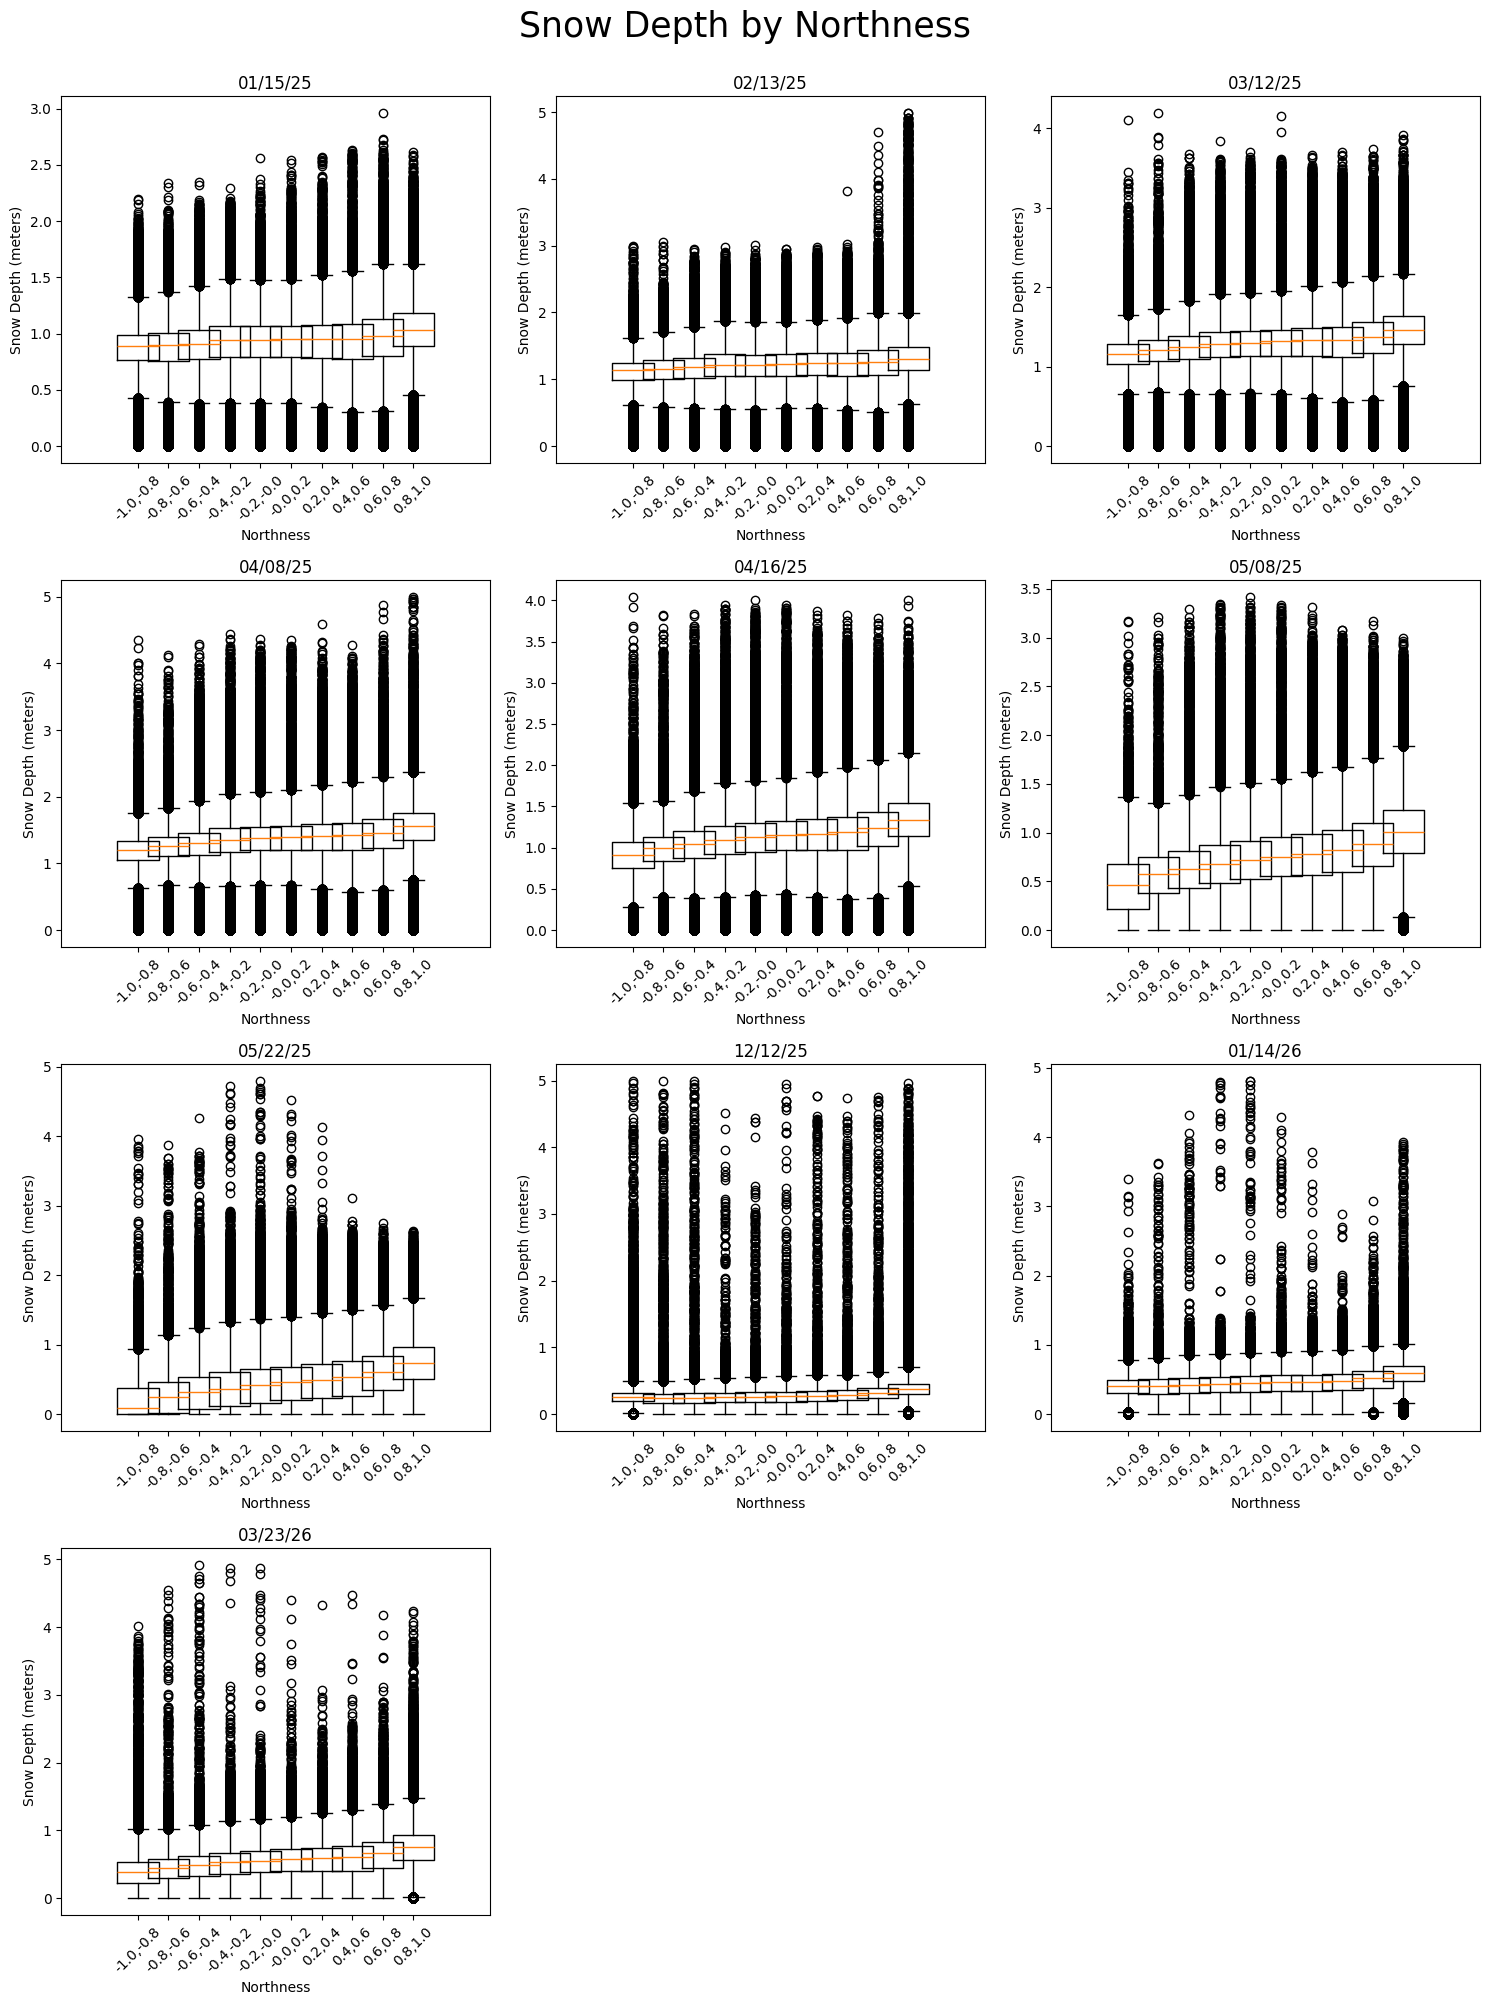

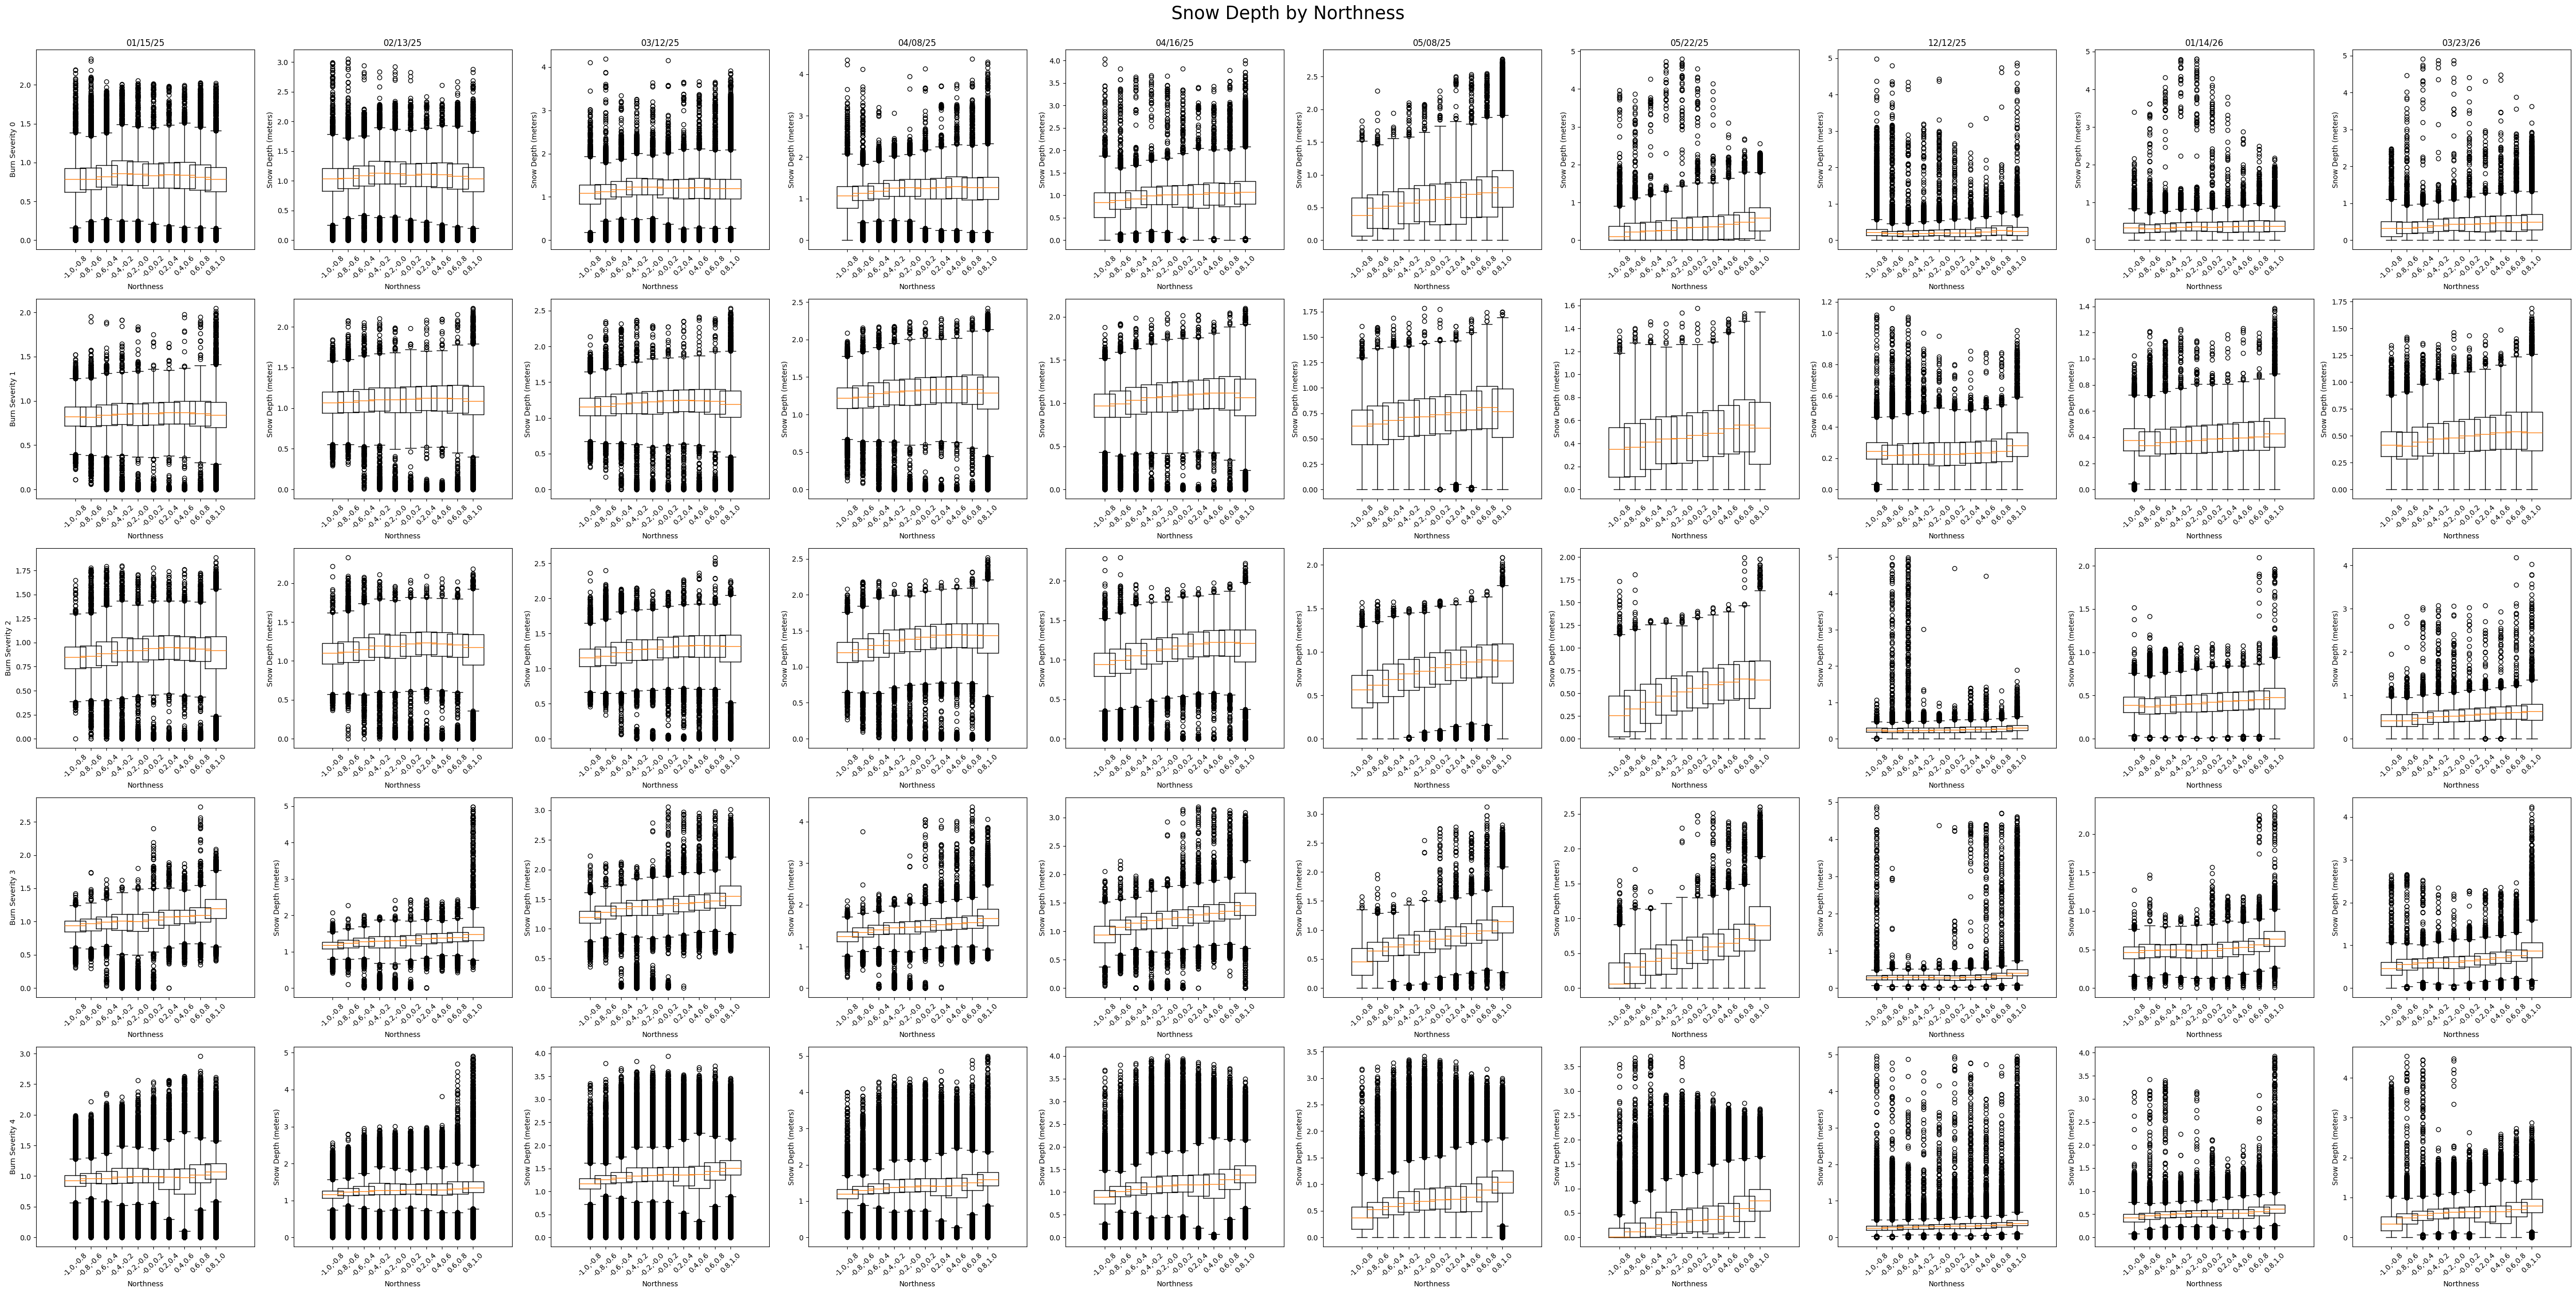

In [29]:
#Replace dems with snow change dems
if(False):
    changeDems = []
    for i in range(1, len(dems)):
        changeDem = dems[i].duplicate_with_new_data(dems[i].z - dems[i-1].z)
        changeDem.name = dems[i].name + "Difference"  # keep the later date's name with difference tag on end
        changeDems.append(changeDem)

    dems = changeDems

#Display snow depth rasters in big plot
if(False):
    minVal = min(np.nanmin(dem.z) for dem in dems)
    maxVal = max(np.nanmax(dem.z) for dem in dems)

    def plotSnowRasters(ax, dem):
        image = ax.imshow(dem.z, cmap='terrain', vmin=minVal, vmax=maxVal)
        ax.figure.colorbar(image, ax=ax, label='Snow Depth (m)')

    makeBigPlot("Snow Depth Raster", plotSnowRasters)

#Box plots of snow depth by day.
if(False):
    def plotBurnSeverity(ax, dem):
        #get depths (resample & filter depths)
        depths = dem.z.ravel()
        bsData = bsDem.z.ravel()

        #filter out any points where depths or burn severirty is nan
        validMask = ~(np.isnan(depths) | np.isnan(bsData))
        depths, bsData = depths[validMask], bsData[validMask]

        #group depths by burn severity
        bsCategories = sorted(np.unique(bsData))
        groupedDepths = []
        for cat in bsCategories: #meow
            groupedDepths.append(depths[bsData == cat])

        #create plot
        ax.boxplot(groupedDepths, positions=bsCategories)
        ax.set_xlabel("Burn Severity")
        ax.set_ylabel("Snow Depth (meters)")
        ax.set_title(getDemDate(dem))

    makeBigPlot("Snow Depth by Burn Severity", plotBurnSeverity)

#Boxplot of northness.
if(True):
    def plotNorthness(ax, dem):
        #get depths (resample & filter depths)
        depths = dem.z.ravel()
        northnessData = northnessDem.z.ravel()

        #filter out any points where depths or northness is nan
        validMask = ~(np.isnan(depths) | np.isnan(northnessData))
        depths, northnessData = depths[validMask], northnessData[validMask]

        #group depths by northness
        nCategories = np.arange(-0.8, 1.2, 0.2) #-0.8 to 1 in steps of 0.2
        groupedDepths = []
        for cat in nCategories: #meow
            mask = (northnessData >= (cat - 0.2)) & (northnessData < cat)
            groupedDepths.append(depths[mask]) #group depths on their range ex: -1, -0.8

        #create plot
        labels = [f"{cat-0.2:.1f},{cat:.1f}" for cat in nCategories] #custom category labels
        ax.tick_params(axis='x', rotation=45) #rotate labels
        ax.boxplot(groupedDepths, positions=nCategories, tick_labels = labels)
        ax.set_xlabel("Northness")
        ax.set_ylabel("Snow Depth (meters)")
        ax.set_title(getDemDate(dem))

    makeBigPlot("Snow Depth by Northness", plotNorthness)

#Box plot of northness by snow depth by burn severity and date
if(True):
    #get bsData and northnessData since they are the same for each subplot
    bsData = bsDem.z.ravel()
    northnessData = northnessDem.z.ravel()

    #create array of burn severity categories
    bsCategories = [0, 1, 2, 3, 4]#sorted(np.unique(bsData[~np.isnan(bsData)]))

    #create figure
    fig, axes = plt.subplots(len(bsCategories), len(dems), figsize=(5 * len(dems), 5 * len(bsCategories)))
    fig.suptitle("Snow Depth by Northness", fontsize=25, y=1.0)

    #create box plots
    for j, dem in enumerate(dems): #cols
        #get depths (resample & filter)
        depths = dem.z.ravel()

        #filter out any points where depths, northness, or burn severity is nan
        validMask = ~(np.isnan(depths) | np.isnan(bsData) | np.isnan(northnessData))
        depths2, bsData2, northnessData2 = depths[validMask], bsData[validMask], northnessData[validMask]

        for i, cat in enumerate(bsCategories): #rows
            # filter to only this burn severity category
            catMask = bsData2 == cat
            northnessData3 = northnessData2[catMask]
            depths3 = depths2[catMask]

            #group depths by northness
            nCategories = np.arange(-0.8, 1.2, 0.2) #-0.8 to 1 in steps of 0.2
            groupedDepths = []
            for northCat in nCategories: #meow
                northMask = (northnessData3 >= (northCat - 0.2)) & (northnessData3 < northCat)
                groupedDepths.append(depths3[northMask]) #group depths on their range ex: -1, -0.8

            #create plot
            labels = [f"{cat-0.2:.1f},{cat:.1f}" for cat in nCategories] #custom category labels
            axes[i, j].tick_params(axis='x', rotation=45) #rotate labels
            axes[i, j].boxplot(groupedDepths, positions=nCategories, tick_labels = labels)
            axes[i, j].set_xlabel("Northness")

            if i == 0:
                #column header (date)
                axes[0, j].set_title(getDemDate(dem))

            if j == 0:
                #row headers (burn severity)
                axes[i, 0].set_ylabel(f"Burn Severity {int(cat)}")
            else:
                axes[i, j].set_ylabel(f"Snow Depth (meters)")
    
    plt.tight_layout()
    plt.show()